# EDA — FAQ Training Set
Konteks: real-world use case cuma dapat **teks pertanyaan** user (gak ada
category/intent/flags). Jadi EDA ini sengaja HANYA pakai kolom `utterance`,
kolom lain di-drop dari awal.

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from wordcloud import WordCloud

df_raw = pd.read_csv("../faq_dataset_raw/training_set/faq_training_set.csv", sep=",")

# Simulasikan kondisi real: cuma teks pertanyaan yang tersedia
df = df_raw[["utterance"]].copy()
print(f"Jumlah baris: {len(df)}")
df.head()

Jumlah baris: 10000


,utterance
0,i want to know where to modify my purchase
1,can u ask an agent for information about seein...
2,tell me if I can have more than one user account
3,"I want to obtain an invoice, tell me where to ..."
4,"i want to make a review, what do i have to do?"


## Cek Struktur Dasar: missing value & duplikat

In [50]:
print("Missing value:", df["utterance"].isna().sum())

n_exact_dup = df["utterance"].duplicated().sum()
print(f"Baris duplikat persis: {n_exact_dup} ({n_exact_dup/len(df)*100:.2f}%)")

# Near-duplicate sederhana: sama persis setelah di-lowercase & strip whitespace
normalized = df["utterance"].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)
n_norm_dup = normalized.duplicated().sum()
print(f"Duplikat setelah normalisasi ringan (lowercase+strip): {n_norm_dup} ({n_norm_dup/len(df)*100:.2f}%)")

# Cek teks kosong / terlalu pendek (< 3 kata)
word_counts_check = df["utterance"].str.split().str.len()
n_too_short = (word_counts_check < 3).sum()
print(f"Teks dengan < 3 kata: {n_too_short}")

Missing value: 0
Baris duplikat persis: 7 (0.07%)
Duplikat setelah normalisasi ringan (lowercase+strip): 401 (4.01%)
Teks dengan < 3 kata: 2


## Distribusi Panjang Teks (kata & karakter)

            n_words       n_chars
count  10000.000000  10000.000000
mean      10.901100     52.744800
std        3.706466     16.743671
min        2.000000     11.000000
25%        9.000000     42.000000
50%       10.000000     51.000000
75%       13.000000     61.000000
max       28.000000    128.000000


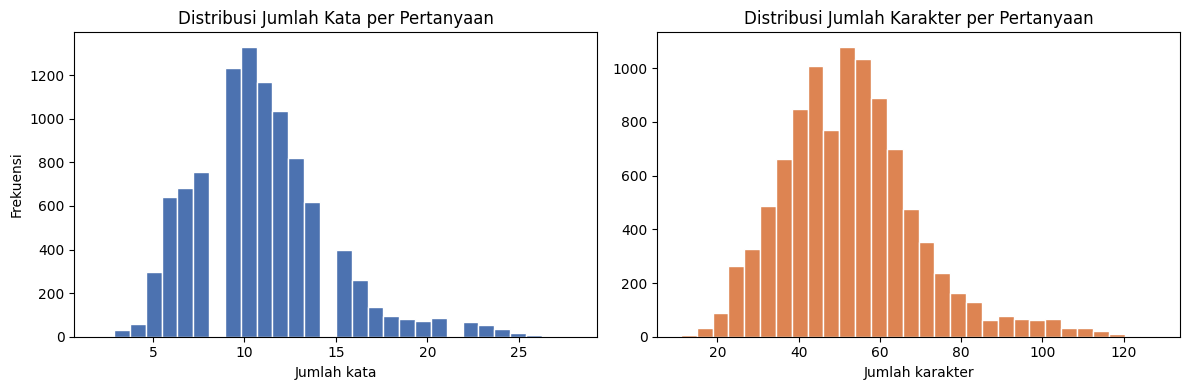

In [51]:
df["n_words"] = df["utterance"].str.split().str.len()
df["n_chars"] = df["utterance"].str.len()

print(df[["n_words", "n_chars"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["n_words"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribusi Jumlah Kata per Pertanyaan")
axes[0].set_xlabel("Jumlah kata")
axes[0].set_ylabel("Frekuensi")

axes[1].hist(df["n_chars"], bins=30, color="#DD8452", edgecolor="white")
axes[1].set_title("Distribusi Jumlah Karakter per Pertanyaan")
axes[1].set_xlabel("Jumlah karakter")

plt.tight_layout()
plt.savefig("eda_length_distribution.png", dpi=120)
plt.show()

## Kata & Frasa Paling Sering Muncul
Catatan: stopword removal DI SINI cuma buat kebutuhan VISUALISASI EDA (biar
wordcloud gak dipenuhi "the/a/i/to"), BUKAN preprocessing yang dipakai buat
embedding nanti (embedding tetap pakai kalimat utuh).

In [52]:
STOPWORDS_EN = set("""
a an the to of and or is are i my me you your it for in on with
do does can could would should have has had be been being this that
""".split())

def tokenize(text):
    return re.findall(r"[a-z']+", text.lower())

all_tokens = [tok for text in df["utterance"] for tok in tokenize(text) if tok not in STOPWORDS_EN]
top_unigrams = Counter(all_tokens).most_common(20)

bigrams = []
for text in df["utterance"]:
    toks = [t for t in tokenize(text) if t not in STOPWORDS_EN]
    bigrams.extend(zip(toks, toks[1:]))
top_bigrams = Counter(bigrams).most_common(15)

print("Top 20 kata:")
for word, count in top_unigrams:
    print(f"  {word:15s} {count}")

print("\nTop 15 frasa 2-kata:")
for (w1, w2), count in top_bigrams:
    print(f"  {w1} {w2:15s} {count}")

Top 20 kata:
  want            2005
  how             1912
  what            1898
  agent           1286
  help            1225
  account         1212
  payment         1208
  ask             1185
  service         1089
  when            900
  please          884
  where           875
  tell            870
  if              810
  was             795
  need            734
  u               711
  information     668
  order           657
  customer        621

Top 15 frasa 2-kata:
  ask agent           1144
  need help            476
  u ask             451
  make payment         415
  was charged         402
  charged anyway          399
  got error           396
  agent how             353
  user account         347
  information about           339
  online account         336
  want know            328
  customer service         326
  client service         313
  agent if              308


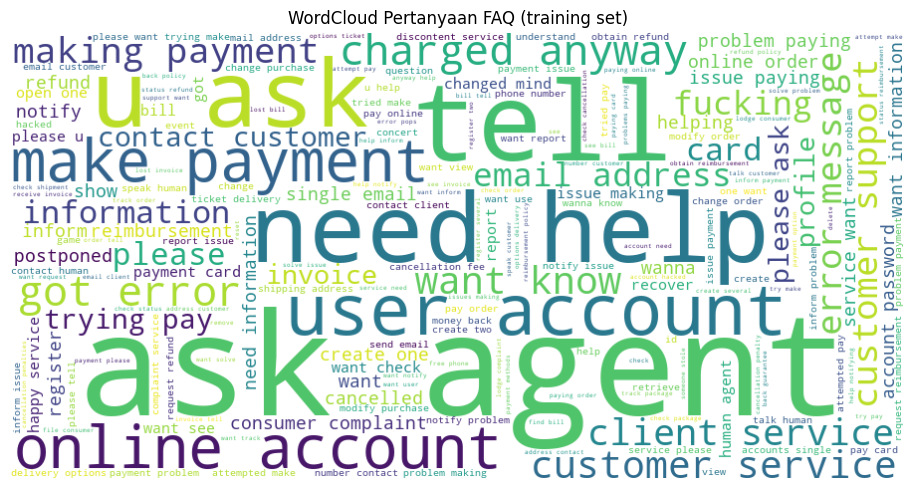

In [53]:
wc_text = " ".join(all_tokens)
wc = WordCloud(width=900, height=450, background_color="white", colormap="viridis").generate(wc_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Pertanyaan FAQ (training set)")
plt.tight_layout()
plt.savefig("eda_wordcloud.png", dpi=120)
plt.show()

## Pola "Kata Pembuka" Pertanyaan
Tanpa label kategori, ini proxy sederhana buat ngeliat ragam "jenis"
pertanyaan yang ada (mis. how/can/i/where/what/do).

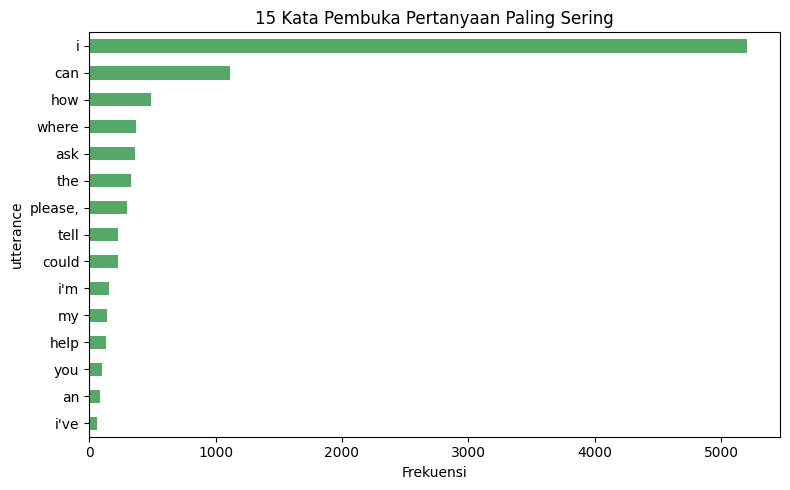

In [54]:
first_words = df["utterance"].str.split().str[0].str.lower()
top_first_words = first_words.value_counts().head(15)

plt.figure(figsize=(8, 5))
top_first_words.sort_values().plot(kind="barh", color="#55A868")
plt.title("15 Kata Pembuka Pertanyaan Paling Sering")
plt.xlabel("Frekuensi")
plt.tight_layout()
plt.savefig("eda_first_words.png", dpi=120)
plt.show()

## Sampling Manual (baca beberapa contoh acak)
Penting buat "merasakan" gaya bahasa data secara kualitatif, gak cuma statistik.

In [55]:
print("Contoh 10 pertanyaan acak:\n")
for text in df["utterance"].sample(10, random_state=42):
    print(f"- {text}")

Contoh 10 pertanyaan acak:

- I got an error message when I attempted to pay, but I was charged anyway, notify it
- i want to inform of a problem making a payment, what do i have to do?
- can u ask an agent how to obtain an invoice?
- how do I see my invoices?
- I haven't got an account, could you create one?
- the game was cancelled, could i obtain a reimbursement?
- the game was postponed, what can I do to get a reimbursement?
- where do i view the status of my refund?
- how do i modify my shipping address?
- how to track my deliveries


# Preprocessing
Tujuan tahap ini: hasilkan teks bersih yang siap di-encode jadi embedding. **Bukan** stopword removal/stemming — sentence-transformer butuh kalimat utuh buat nangkep makna semantik dengan benar.

## 1. Buang teks yang terlalu pendek (< 3 kata)

In [56]:
before = len(df)
df_clean = df[df["n_words"] >= 3].copy()
print(f"Sebelum: {before} baris")
print(f"Sesudah buang teks < 3 kata: {len(df_clean)} baris (buang {before - len(df_clean)})")

Sebelum: 10000 baris
Sesudah buang teks < 3 kata: 9998 baris (buang 2)


## 2. Buang near-duplicate
Dari EDA, exact duplicate cuma 0.07%, tapi near-duplicate (beda casing/whitespace doang) ternyata 4.01%. Kita dedupe berdasarkan versi ternormalisasi (lowercase + strip whitespace), tapi teks ASLI yang disimpan (bukan versi lowercase-nya) — biar casing alami tetap utuh buat sentence-transformer.

In [57]:
before = len(df_clean)
df_clean["_normalized_key"] = (
    df_clean["utterance"].str.lower().str.strip().str.replace(r"\s+", " ", regex=True)
)
df_clean = df_clean.drop_duplicates(subset="_normalized_key", keep="first")
df_clean = df_clean.drop(columns=["_normalized_key"])
print(f"Sebelum: {before} baris")
print(f"Sesudah buang near-duplicate: {len(df_clean)} baris (buang {before - len(df_clean)})")

Sebelum: 9998 baris
Sesudah buang near-duplicate: 9597 baris (buang 401)


## 3. Cleaning ringan (whitespace & karakter aneh)
Cuma normalisasi ringan — TIDAK lowercase paksa, TIDAK hapus tanda baca, TIDAK stopword removal. Sentence-transformer modern sudah case-aware dan butuh tanda baca buat nangkep struktur kalimat.

In [58]:
import unicodedata

def light_clean(text):
    text = unicodedata.normalize("NFKC", text)          # normalisasi unicode (mis. karakter aneh hasil encoding)
    text = re.sub(r"\s+", " ", text).strip()             # rapikan whitespace berlebih
    return text

df_clean["utterance_clean"] = df_clean["utterance"].apply(light_clean)

# Cek: ada berapa baris yang berubah setelah cleaning ringan ini
n_changed = (df_clean["utterance_clean"] != df_clean["utterance"]).sum()
print(f"Baris yang berubah karena cleaning ringan: {n_changed}")

Baris yang berubah karena cleaning ringan: 178


## 4. Simpan hasil preprocessing
File `cleaned_text.csv` inilah yang jadi input tahap embedding berikutnya.

In [59]:
final_df = df_clean[["utterance_clean"]].rename(columns={"utterance_clean": "utterance"})
final_df = final_df.reset_index(drop=True)
final_df.to_csv("faq_dataset_preprocessing/cleaned_text.csv", index=False)

print(f"Total baris awal   : {len(df)}")
print(f"Total baris final  : {len(final_df)}")
print(f"Total baris dibuang: {len(df) - len(final_df)} ({(len(df)-len(final_df))/len(df)*100:.2f}%)")
print("\nDisimpan ke: faq_dataset_preprocessing/cleaned_text.csv") 
final_df.head()

Total baris awal   : 10000
Total baris final  : 9597
Total baris dibuang: 403 (4.03%)

Disimpan ke: faq_dataset_preprocessing/cleaned_text.csv


,utterance
0,i want to know where to modify my purchase
1,can u ask an agent for information about seein...
2,tell me if I can have more than one user account
3,"I want to obtain an invoice, tell me where to ..."
4,"i want to make a review, what do i have to do?"


## 5. Generate Embedding

In [60]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np

df_final = pd.read_csv("faq_dataset_preprocessing/cleaned_text.csv")

# Model kecil & cepat, cocok buat kalimat pendek (bahasa Inggris)
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df_final["utterance"].tolist(),
    show_progress_bar=True,
    batch_size=64
)

print(f"faq_dataset_preprocessing/Shape embedding: {embeddings.shape}")  # (9597, 384)

# %%
np.save("faq_dataset_preprocessing/embeddings.npy", embeddings)
print("Disimpan ke: faq_dataset_preprocessing/embeddings.npy")


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/150 [00:00<?, ?it/s]

faq_dataset_preprocessing/Shape embedding: (9597, 384)
Disimpan ke: faq_dataset_preprocessing/embeddings.npy
